In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.multioutput import MultiOutputRegressor
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier, XGBRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score


In [2]:
URL = 'https://github.com/Kabir26-star/CAS-ADS-Module-3/blob/main/divorce_df.csv?raw=true'

df = pd.read_csv(URL)
df

,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
0,30,1,1,Bachelor,Full-time,64001,Different Religion,1,5.536016,3,...,0,0,0,8.428183,5,Love,1,0,6.262411,1
1,27,2,2,Master,Full-time,86221,Same Religion,1,5.810172,3,...,0,1,0,5.297221,1,Love,1,0,6.769384,1
2,31,6,0,High School,Part-time,69441,Same Religion,0,6.088146,3,...,0,0,0,5.887066,1,Arranged,1,0,5.532866,1
3,35,3,2,Bachelor,Full-time,69513,Not Religious,1,6.212046,3,...,0,0,0,5.263555,5,Love,1,0,3.491264,0
4,26,2,2,No Formal Education,Full-time,63986,Different Religion,1,4.826262,1,...,0,0,1,5.771259,4,Love,1,0,10.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,27,1,3,Master,Full-time,67410,Same Religion,1,7.406795,1,...,0,0,0,4.071359,4,Arranged,1,0,6.333963,0
4996,31,21,2,Bachelor,Homemaker,88995,Same Religion,1,3.971897,2,...,0,1,1,3.064645,3,Love,1,0,3.279566,0
4997,43,13,2,Bachelor,Homemaker,93184,Same Religion,0,10.000000,4,...,1,0,0,7.728128,3,Other,0,0,4.002068,1
4998,32,1,2,Master,Part-time,54132,Same Religion,1,3.382175,2,...,0,0,0,8.827352,3,Arranged,1,0,3.790967,0


In [3]:
df_copy = df.copy()

print("Dataset copied successfully to df_copy.")
display(df_copy.head(10))

Dataset copied successfully to df_copy.


,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
0,30,1,1,Bachelor,Full-time,64001,Different Religion,1,5.536016,3,...,0,0,0,8.428183,5,Love,1,0,6.262411,1
1,27,2,2,Master,Full-time,86221,Same Religion,1,5.810172,3,...,0,1,0,5.297221,1,Love,1,0,6.769384,1
2,31,6,0,High School,Part-time,69441,Same Religion,0,6.088146,3,...,0,0,0,5.887066,1,Arranged,1,0,5.532866,1
3,35,3,2,Bachelor,Full-time,69513,Not Religious,1,6.212046,3,...,0,0,0,5.263555,5,Love,1,0,3.491264,0
4,26,2,2,No Formal Education,Full-time,63986,Different Religion,1,4.826262,1,...,0,0,1,5.771259,4,Love,1,0,10.000000,1
5,26,10,0,High School,Full-time,44605,Same Religion,0,6.825964,3,...,0,0,0,6.909350,3,Love,1,0,4.628149,0
6,35,10,2,High School,Full-time,73454,Different Religion,1,3.775491,1,...,0,0,0,7.351375,1,Love,1,0,5.753932,0
7,31,17,1,High School,Unemployed,59491,Not Religious,1,6.613021,4,...,0,0,0,8.709813,2,Love,0,0,7.010559,1
8,25,5,1,Bachelor,Full-time,40944,Not Religious,0,2.963345,0,...,0,0,0,8.727489,3,Arranged,1,0,2.428385,0
9,30,1,0,PhD,Full-time,46819,Same Religion,1,3.612109,1,...,1,0,0,5.939285,1,Arranged,1,0,8.750676,1


In [ ]:
# Visualize continuous variables with histograms (excluding 'divorced') by divorced status
continuous_cols = df_copy.select_dtypes(include=np.number).drop(columns=['divorced'])
n_cols = 4  # Number of columns for subplots
n_rows = (len(continuous_cols.columns) + n_cols - 1) // n_cols  # Calculate number of rows

plt.figure(figsize=(n_cols * 5, n_rows * 4)) # Adjust figure size based on number of plots

for i, col in enumerate(continuous_cols.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data=df_copy, x=col, hue='divorced', kde=True, multiple='stack') # Use hue to differentiate divorced groups

    # calculate mean values
    mean_non_div = df_copy[df_copy['divorced'] == 0][col].mean()
    mean_div = df_copy[df_copy['divorced'] == 1][col].mean()

    # Add mean Lines
    plt.axvline(mean_non_div, color='b', linestyle='--', linewidth=1.5, label='Mean Non-Divorced')
    plt.axvline(mean_div, color='r', linestyle='--', linewidth=1.5, label='Mean Divorced')


    plt.title(f'Distribution of {col} by Divorced Status')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='lightgray') # Add light gray grid

plt.tight_layout()
plt.show()

In [ ]:
# Visualize categorical and binary variables with count plots by divorced status
categorical_cols = df_copy.select_dtypes(include='object')

# Filter out columns that resulted in empty plots (based on previous execution output)
# The columns that resulted in empty Series were:
# 'cultural_background_match', 'mental_health_issues', 'infidelity_occurred',
# 'counseling_attended', 'pre_marital_cohabitation', 'domestic_violence_history'
cols_to_exclude = ['cultural_background_match', 'mental_health_issues', 'infidelity_occurred',
                   'counseling_attended', 'pre_marital_cohabitation', 'domestic_violence_history']
categorical_cols = categorical_cols.drop(columns=cols_to_exclude, errors='ignore')


n_cols = 3  # Number of columns for subplots
n_rows = (len(categorical_cols.columns) + n_cols - 1) // n_cols  # Calculate number of rows

plt.figure(figsize=(n_cols * 6, n_rows * 6)) # Adjust figure size based on number of plots

for i, col in enumerate(categorical_cols.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(data=df_copy, x=col, hue='divorced', order=df_copy[col].value_counts().index) # Use hue to differentiate divorced groups
    plt.title(f'Count of {col} by Divorced Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Divorced', labels=['Non Divorced', 'Divorced'])
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='lightgray') # Add light gray grid

plt.tight_layout()
plt.show()

In [ ]:
# Separate continuous and categorical/binary variables

# Identify binary columns (only contain 0 and 1)
binary_cols = df_copy.columns[(df_copy.nunique() == 2) & (df_copy.apply(lambda x: set(x.unique()) == {0, 1} or set(x.unique()) == {0} or set(x.unique()) == {1}).all())].tolist()

# Identify categorical columns (object dtype and not binary)
categorical_cols = df_copy.select_dtypes(include='object').columns.tolist()

# Identify continuous columns (numeric dtype and not binary)
continuous_cols = df_copy.select_dtypes(include=np.number).columns.tolist()
continuous_cols = [col for col in continuous_cols if col not in binary_cols]

print("Continuous Variables:")
print(continuous_cols)

print("\nBinary Variables:")
print(binary_cols)

print("\nCategorical Variables:")
print(categorical_cols)

# Summary for continuous variables (Mean and Standard Deviation) by Divorced Status
print("\nSummary of Continuous Variables (Mean and Standard Deviation) by Divorced Status:")
print(df_copy.groupby('divorced')[continuous_cols].agg(['mean', 'std']).T)

print("\nPercentages for Categorical and Binary Variables by Divorced Status:")
# Create a dictionary to store categorical summaries
categorical_binary_summaries = {}
for col in categorical_cols + binary_cols:
    print(f"\nColumn: {col}")
    col_summary = df_copy.groupby('divorced')[col].value_counts(normalize=True).mul(100).round(2).astype(str) + '%'
    print(col_summary)
    categorical_binary_summaries[col] = col_summary.unstack(level=0) # Unstack to get divorced status as columns

# Example of how to access a specific categorical summary DataFrame
# education_level_summary_df = categorical_binary_summaries['education_level']
# display(education_level_summary_df)

In [ ]:
# Step 1: Separate Data by Divorced Status
df_divorced = df_copy[df_copy['divorced'] == 1]
df_nondivorced = df_copy[df_copy['divorced'] == 0]

print("Data successfully separated by divorced status.")
print(f"Divorced group shape: {df_divorced.shape}")
print(f"Non-divorced group shape: {df_nondivorced.shape}")

In [ ]:
# Step 2: Analyze Continuous Variables

from scipy.stats import ttest_ind, probplot, shapiro, levene, mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Analyzing Continuous Variables:")

# Exclude 'divorced' column from continuous variables for t-test
continuous_cols_for_test = [col for col in continuous_cols if col != 'divorced']

for col in continuous_cols_for_test:
    print(f"\nAnalyzing column: {col}")

    # Separate the data for the two groups
    group1 = df_divorced[col].dropna()  # Divorced group
    group0 = df_nondivorced[col].dropna() # Non-divorced group

    # Check for sufficient data in both groups
    if len(group1) < 2 or len(group0) < 2:
        print(f"Skipping analysis for {col} due to insufficient data in one or both groups.")
        continue

    # Test of Assumption: Normality (Shapiro-Wilk Test and QQ Plots)
    print("\nTest of Assumption: Normality (Shapiro-Wilk Test and QQ Plots)")
    print("Note: Non-parametric tests do not assume normality, but understanding the distribution is still helpful.")

    # Shapiro-Wilk Test for Normality
    # Null Hypothesis (H0): The data is drawn from a normal distribution.
    # Working Hypothesis (H1): The data is not drawn from a normal distribution.
    shapiro_group1 = shapiro(group1)
    shapiro_group0 = shapiro(group0)

    print(f"\nShapiro-Wilk Test for {col} (Divorced Group):")
    print(f"Statistic: {shapiro_group1.statistic:.4f}, P-value: {shapiro_group1.pvalue:.4f}")
    if shapiro_group1.pvalue < 0.05:
        print("Conclusion: Reject the null hypothesis. The data in the divorced group is likely not normally distributed.")
    else:
        print("Conclusion: Fail to reject the null hypothesis. The data in the divorced group may be normally distributed.")

    print(f"\nShapiro-Wilk Test for {col} (Non-Divorced Group):")
    print(f"Statistic: {shapiro_group0.statistic:.4f}, P-value: {shapiro_group0.pvalue:.4f}")
    if shapiro_group0.pvalue < 0.05:
        print("Conclusion: Reject the null hypothesis. The data in the non-divorced group is likely not normally distributed.")
    else:
        print("Conclusion: Fail to reject the null hypothesis. The data in the non-divorced group may be normally distributed.")

    # Generate QQ Plots to visually check normality assumption
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    probplot(group1, dist="norm", plot=plt)
    plt.title(f'QQ Plot for {col} (Divorced)')
    plt.xlabel('Theoretical Quantiles')
    plt.ylabel('Sample Quantiles')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    probplot(group0, dist="norm", plot=plt)
    plt.title(f'QQ Plot for {col} (Non-Divorced)')
    plt.xlabel('Theoretical Quantiles')
    plt.ylabel('Sample Quantiles')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Test of Assumption: Equality of Variances (Levene's Test)
    print("\nTest of Assumption: Equality of Variances (Levene's Test)")
    print("Null Hypothesis (H0): The variances of {col} are equal for divorced and non-divorced groups.")
    print("Working Hypothesis (H1): The variances of {col} are not equal for divorced and non-divorced groups.")
    levene_result = levene(group1, group0)
    print(f"Levene's Test Statistic: {levene_result.statistic:.4f}, P-value: {levene_result.pvalue:.4f}")

    if levene_result.pvalue < 0.05:
        print("Conclusion: Reject the null hypothesis. The variances are likely unequal.")
    else:
        print("Conclusion: Fail to reject the null hypothesis. The variances may be equal.")


    # Perform Mann-Whitney U Test (Non-parametric alternative to Independent Samples T-test)
    print("\nPerforming Mann-Whitney U Test:")
    print(f"Null Hypothesis (H0): The distribution of {col} is the same for divorced and non-divorced groups.")
    print(f"Working Hypothesis (H1): The distribution of {col} is different for divorced and non-divorced groups.")
    mannwhitneyu_result = mannwhitneyu(group1, group0)

    print(f"\nMann-Whitney U Test Results for {col}:")
    print(f"Statistic: {mannwhitneyu_result.statistic:.4f}")
    print(f"P-value: {mannwhitneyu_result.pvalue:.4f}")

    alpha = 0.05
    if mannwhitneyu_result.pvalue < alpha:
        print(f"Conclusion: Reject the null hypothesis. There is a significant difference in the distribution of {col} between divorced and non-divorced groups.")
    else:
        print(f"Conclusion: Fail to reject the null hypothesis. There is no significant difference in the distribution of {col} between divorced and non-divorced groups.")

    # Visualize with Histogram
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df_copy, x=col, hue='divorced', kde=True, multiple='stack')
    plt.title(f'Distribution of {col} by Status') # Updated title
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='lightgray')
    plt.legend(title='Status', labels=['Non-Divorced', 'Divorced']) # Updated legend title
    plt.tight_layout()
    plt.show()

    # Visualize with Box Plot
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_copy, x='divorced', y=col)
    plt.title(f'Distribution of {col} by Status') # Updated title
    plt.xlabel('Status') # Updated x-axis label
    plt.ylabel(col)
    plt.xticks([0, 1], ['Non-Divorced', 'Divorced'])
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='lightgray')
    plt.tight_layout()
    plt.show()

In [ ]:
# Hypothesis Testing for Categorical Variables
# Using Chi-Squared Test and Bar Plots

from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

print("Hypothesis Testing for Categorical Variables:")

# Use the categorical_cols identified earlier
for col in categorical_cols:
    print(f"\nTesting Hypothesis for column: {col}")

    # Create a contingency table
    contingency_table = pd.crosstab(df_copy[col], df_copy['divorced'])
    print(f"Observed Contingency Table for {col} vs Divorced:")
    print(contingency_table)

    # Chi-Squared Test
    # Null Hypothesis (H0): No association between {col} and divorced status.
    # Alternative Hypothesis (H1): There is a association.
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    print(f"\nChi-Squared Test Results for {col}:")
    print(f"Chi-Statistic: {chi2:.4f}")
    print(f"P-value: {p:.4f}")
    print(f"Degrees of Freedom: {dof}")

    alpha = 0.05
    if p < alpha:
        print(f"Conclusion: Reject the null hypothesis. There is a significant association between {col} and divorced status.")
    else:
        print(f"Conclusion: Fail to reject the null hypothesis. There is no significant association between {col} and divorced status.")

    # Visualize with Bar Plot
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_copy, x=col, hue='divorced', order=df_copy[col].value_counts().index)
    plt.title(f'{col} Divorce by Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Divorce Status', labels=['Non-Divorced', 'Divorced']) # Update legend labels and title
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='lightgray')
    plt.tight_layout()
    plt.show()

**Age Distribution**

In [ ]:
sns.histplot(x='age_at_marriage', data=df_copy, kde=True, stat='density', bins=30)
plt.title('Distribution of Age at Marriage')
plt.xlabel('Age at Marriage')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Social Support**

In [ ]:
X = df.drop([
    'num_children', 'education_level', 'employment_status', 'combined_income',
    'religious_compatibility', 'cultural_background_match', 
    'conflict_frequency', 'mental_health_issues', 'infidelity_occurred',
    'counseling_attended', 'shared_hobbies_count', 'marriage_type',
    'pre_marital_cohabitation', 'domestic_violence_history'
], axis=1)

Y = df['social_support']

In [ ]:
X_train, x_test, Y_train, y_test = train_test_split(X,Y,test_size=0.2, random_state = 42)

In [ ]:
categorical_cols = ['conflict_resolution_style']

# all remaining columns are numeric
numeric_cols = [col for col in X.columns if col not in categorical_cols]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)



In [ ]:
xgb_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', XGBRegressor(
        n_estimators=1200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

In [ ]:
xgb_model.fit(X_train, Y_train)



In [ ]:
y_prediction = xgb_model.predict(x_test)

mse = mean_squared_error(y_test, y_prediction)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_prediction)
r2 = r2_score(y_test, y_prediction)

print("Regression metrics for Social Support (XGBoost Pipeline):")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R^2: {r2:.4f}")

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_prediction, color='red')
plt.xlabel("Actual Social Support Status")
plt.ylabel("Predicted Social Support Status")
plt.title("Actual vs Predicted Social Support Status")
plt.grid(True)
plt.show()

**Trust Score**


In [ ]:
X = df.drop([
    'num_children', 'education_level', 'employment_status', 'combined_income',
    'religious_compatibility', 'cultural_background_match', 
    'conflict_frequency', 'mental_health_issues', 'infidelity_occurred',
    'counseling_attended', 'shared_hobbies_count', 'marriage_type',
    'pre_marital_cohabitation', 'domestic_violence_history'
], axis=1)

Y = df['trust_score']

In [ ]:
categorical_cols = ['conflict_resolution_style']

# all remaining columns are numeric
numeric_cols = [col for col in X.columns if col not in categorical_cols]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)


In [ ]:
xgb_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', XGBRegressor(
        n_estimators=1200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

In [ ]:
X_train, x_test, Y_train, y_test = train_test_split(X,Y,test_size=0.2, random_state = 42)

In [ ]:
xgb_pipeline.fit(X_train, Y_train)

In [ ]:
y_pred = xgb_pipeline.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Regression metrics for Trust Score (XGBoost Pipeline):")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R^2: {r2:.4f}")

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Trust Score")
plt.ylabel("Predicted Trust Score")
plt.title("Actual vs Predicted Trust Score (XGBoost Pipeline)")
plt.grid(True)
plt.show()

**Communication Score**

In [ ]:
X = df.drop([
    'num_children', 'education_level', 'employment_status', 'combined_income',
    'religious_compatibility', 'cultural_background_match',
    'conflict_frequency', 'mental_health_issues', 'infidelity_occurred',
    'counseling_attended', 'shared_hobbies_count', 'marriage_type',
    'pre_marital_cohabitation', 'domestic_violence_history'
], axis=1)

Y = df['communication_score']

In [ ]:
categorical_cols = ['conflict_resolution_style']

# all remaining columns are numeric
numeric_cols = [col for col in X.columns if col not in categorical_cols]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)


In [ ]:
xgb_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', XGBRegressor(
    n_estimators=1200,
    learning_rate=0.02,
    max_depth=9,
    subsample=0.85,
    colsample_bytree=0.9,
    reg_lambda=2,
    reg_alpha=1,
    gamma=0.3,
    min_child_weight=3,
    random_state=42
    ))
])

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
xgb_pipeline.fit(X_train, Y_train)

In [ ]:
predict = xgb_pipeline.predict(X_test)

mse = mean_squared_error(Y_test, predict)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, predict)
r2 = r2_score(Y_test, predict)

print("Regression metrics for Communication Score (XGBoost Pipeline):")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R^2: {r2:.4f}")

In [ ]:
plt.scatter(Y_test, predict)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.xlabel("Actual Communication Score")
plt.ylabel("Predicted Communication Score")
plt.title("Actual vs Predicted Communication Score (XGBoost)")
plt.grid(True)
plt.show()


**Financial Stress Level**

In [ ]:
X = df.drop([
    'marriage_duration_years', 'num_children', 'education_level', 'employment_status',
    'combined_income', 'religious_compatibility', 'cultural_background_match',
     'conflict_frequency', 'mental_health_issues',
    'infidelity_occurred', 'counseling_attended', 'social_support',
    'shared_hobbies_count', 'marriage_type', 'pre_marital_cohabitation',
    'domestic_violence_history'
], axis=1)

Y = df['financial_stress_level']

In [ ]:
categorical_cols = ['conflict_resolution_style']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)


In [ ]:
xgb_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', XGBRegressor(
    n_estimators=1200,
    learning_rate=0.02,
    max_depth=9,
    subsample=0.85,
    colsample_bytree=0.9,
    reg_lambda=2,
    reg_alpha=1,
    gamma=0.3,
    min_child_weight=3,
    random_state=42
    ))
])

In [ ]:
X_train, x_test, Y_train, y_test = train_test_split(X,Y,test_size=0.2, random_state = 42)

In [ ]:
xgb_pipeline.fit(X_train, Y_train)

In [ ]:
pred = xgb_pipeline.predict(x_test)

In [ ]:
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("Regression metrics for Financial Stress Level (XGBoost Pipeline):")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R^2: {r2:.4f}")


In [ ]:
plt.scatter(y_test, pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Stress Level")
plt.ylabel("Predicted Stress Level")
plt.title("Actual vs Predicted Stress Level (XGBoost)")
plt.grid(True)
plt.show()


**Machine Learning using XGB Boost**

In [107]:
X = df.drop(['marriage_duration_years',  'num_children', 'education_level',      'employment_status',    'combined_income',      'religious_compatibility',      'cultural_background_match',    'communication_score',  'conflict_frequency',    'mental_health_issues', 'infidelity_occurred',  'counseling_attended',  'social_support',       'shared_hobbies_count', 'marriage_type',        'pre_marital_cohabitation',     'domestic_violence_history'], axis=1)
Y = df['divorced']

In [ ]:
X_train, x_test, Y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [108]:
# Encode categorical columns (if any) before scaling
categorical_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()


In [109]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # keep numeric columns as-is
)


In [110]:
# XGBoost pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])


In [112]:
# Fit pipeline
pipeline.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [114]:
# Predict
y_pred = pipeline.predict(X_test)

In [117]:
# Flatten in case they are DataFrames or 2D arrays
y_test = np.ravel(y_test)
y_pred = np.ravel(y_pred)

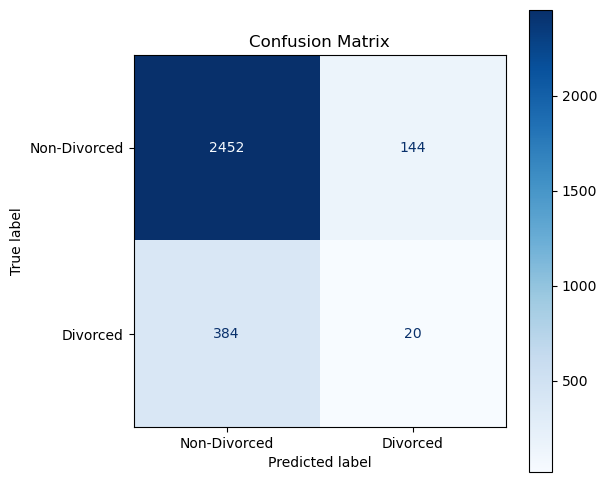

Accuracy: 0.824

Classification Report:

              precision    recall  f1-score   support

Non-Divorced       0.86      0.94      0.90      2596
    Divorced       0.12      0.05      0.07       404

    accuracy                           0.82      3000
   macro avg       0.49      0.50      0.49      3000
weighted avg       0.76      0.82      0.79      3000



In [118]:
labels = np.unique(np.concatenate([y_test, y_pred]))
display_map = {0: 'Non-Divorced', 1: 'Divorced'}
display_labels = [display_map.get(l, str(l)) for l in labels]

cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Metrics
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, labels=labels, target_names=display_labels))

**Random Forest**

In [119]:
X = df.drop(['marriage_duration_years',  'num_children', 'education_level',      'employment_status',    'combined_income',      'religious_compatibility',      'cultural_background_match',    'communication_score',  'conflict_frequency',    'mental_health_issues', 'infidelity_occurred',  'counseling_attended',  'social_support',       'shared_hobbies_count', 'marriage_type',        'pre_marital_cohabitation',     'domestic_violence_history'], axis=1)
Y = df['divorced']

In [120]:
X_train, x_test, Y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [121]:
# Encode categorical columns (if any) before scaling
categorical_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()

In [122]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # keep numeric columns as-is
)


In [131]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=1000,
        random_state=42,
        class_weight='balanced',  # handle class imbalance
        n_jobs=-1
    ))
])

In [132]:
# Fit pipeline
rf_pipeline.fit(X_train, Y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [133]:
# Predict
pred = pipeline.predict(x_test)

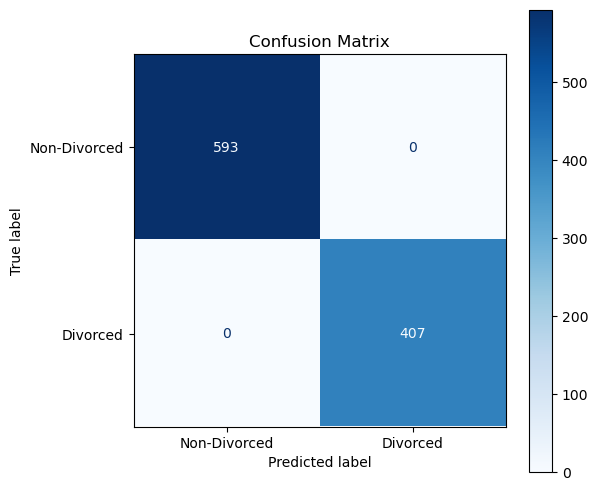

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

Non-Divorced       1.00      1.00      1.00       593
    Divorced       1.00      1.00      1.00       407

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [136]:
labels = np.unique(np.concatenate([y_test, pred]))
display_map = {0: 'Non-Divorced', 1: 'Divorced'}
display_labels = [display_map.get(l, str(l)) for l in labels]

cm = confusion_matrix(y_test, pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Metrics
print('Accuracy:', accuracy_score(y_test, pred))
print('\nClassification Report:\n')
print(classification_report(y_test, pred, labels=labels, target_names=display_labels))

**Pipeline for Random Forest**

In [5]:
numerical_features = [
    "communication_score",
    "trust_score",
    "social_support"
]

target_cols = [
    "infidelity_occurred",
    "domestic_violence_history",
    "mental_health_issues"
]

In [6]:
X = df[numerical_features]
Y = df[target_cols]


In [7]:
models = {}
scores = {}

for target in target_cols:
   Y = df[target_cols].copy()

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y[target_cols])

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features)
    ]
)

In [10]:
# Fit separate pipeline per target with SMOTE
pipelines = {}
for target in target_cols:
    smote_pipeline = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight='balanced'
        ))
    ])
    pipelines[target] = smote_pipeline
    pipelines[target].fit(X_train, Y_train[target])

In [11]:
# Predictions and evaluation
y_pred_df = pd.DataFrame()
for target in target_cols:
    y_pred_df[target] = pipelines[target].predict(X_test)


Target: infidelity_occurred — Accuracy: 0.7000


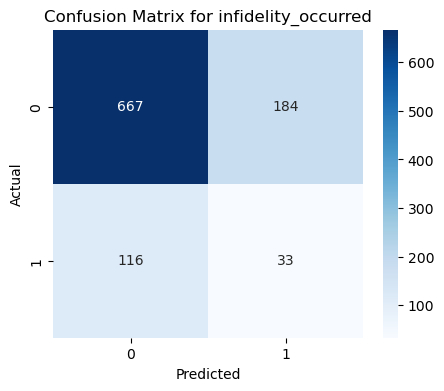


Classification Report for infidelity_occurred:

              precision    recall  f1-score   support

           0       0.85      0.78      0.82       851
           1       0.15      0.22      0.18       149

    accuracy                           0.70      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.75      0.70      0.72      1000

------------------------------------------------------------

Target: domestic_violence_history — Accuracy: 0.8140


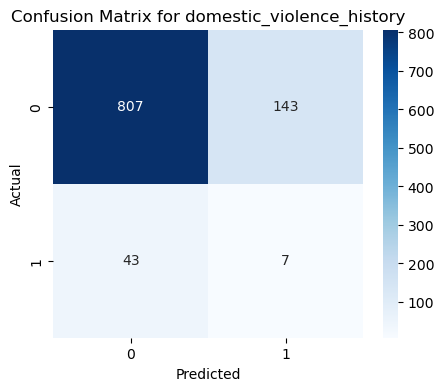


Classification Report for domestic_violence_history:

              precision    recall  f1-score   support

           0       0.95      0.85      0.90       950
           1       0.05      0.14      0.07        50

    accuracy                           0.81      1000
   macro avg       0.50      0.49      0.48      1000
weighted avg       0.90      0.81      0.86      1000

------------------------------------------------------------

Target: mental_health_issues — Accuracy: 0.6420


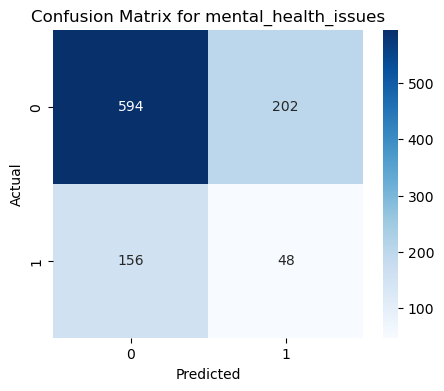


Classification Report for mental_health_issues:

              precision    recall  f1-score   support

           0       0.79      0.75      0.77       796
           1       0.19      0.24      0.21       204

    accuracy                           0.64      1000
   macro avg       0.49      0.49      0.49      1000
weighted avg       0.67      0.64      0.65      1000

------------------------------------------------------------


In [19]:
for target in target_cols:
    y_true = Y_test[target]
    y_pred = y_pred_df[target]

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    
    print(f"\nTarget: {target} — Accuracy: {acc:.4f}")
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix for {target}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification report for this target
    print(f"\nClassification Report for {target}:\n")
    print(classification_report(y_true, y_pred))
    print("-" * 60)

**Pipeline for XGBoost**

In [53]:
numerical_features = [
    "communication_score",
    "trust_score",
    "social_support"
]

target_cols = [
    "infidelity_occurred",
    "domestic_violence_history",
    "mental_health_issues"
]


In [54]:
X = df[numerical_features]
Y = df[target_cols]


In [56]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y[target_cols])

In [57]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features)
    ]
)

In [58]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MultiOutputClassifier(
        XGBClassifier(n_estimators=200, random_state=42)
    ))
])

In [88]:
pipelines = {}

for target in target_cols:
    smote_pipeline = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            learning_rate=0.05,
            max_depth=5,
            n_estimators=300,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
          
        ))
    ])
    
    pipelines[target] = smote_pipeline
    pipelines[target].fit(X_train, Y_train[target])

In [89]:
# Predict for each target and store in DataFrame
y_pred_df = pd.DataFrame()

for target in target_cols:
    y_pred_df[target] = pipelines[target].predict(X_test)



Target: infidelity_occurred — Accuracy: 0.5730
Confusion Matrix:
[[528 323]
 [104  45]]


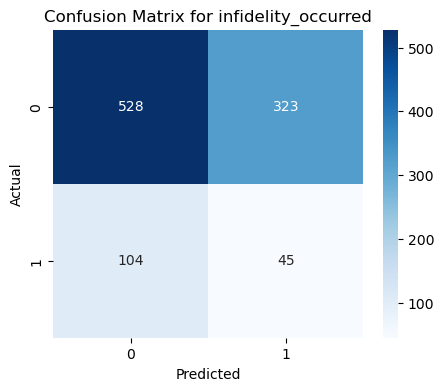


Target: domestic_violence_history — Accuracy: 0.7320
Confusion Matrix:
[[719 231]
 [ 37  13]]


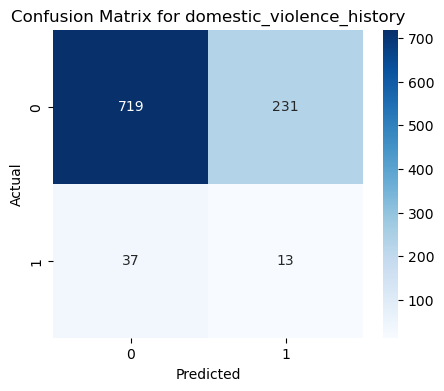


Target: mental_health_issues — Accuracy: 0.5710
Confusion Matrix:
[[497 299]
 [130  74]]


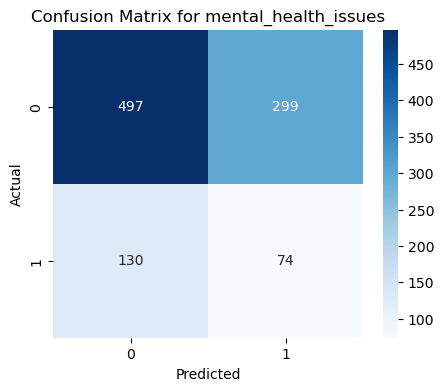

In [90]:
# Plot confusion matrices and print accuracy
for target in target_cols:
    cm = confusion_matrix(Y_test[target], y_pred_df[target])
    acc = accuracy_score(Y_test[target], y_pred_df[target])
    
    print(f"\nTarget: {target} — Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix for {target}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

**Logistic Regression**

In [77]:
numerical_features = [
    "communication_score",
    "trust_score",
    "social_support"
]

target_cols = [
    "infidelity_occurred",
    "domestic_violence_history",
    "mental_health_issues"
]

In [78]:
X = df[numerical_features]
Y = df[target_cols]

In [99]:
X_train, X_test, Y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [100]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features)
    ]
)

In [101]:
pipelines = {}

for target in target_cols:
    pipeline = ImbPipeline([
        ("preprocessor", ColumnTransformer([
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numerical_features)
        ])),
        ("smote", SMOTE(random_state=42)),  # oversample minority class
        ("classifier", LogisticRegression(
            solver='liblinear',
            class_weight='balanced',  # optional with SMOTE
            random_state=42
        ))
    ])
    
    pipelines[target] = pipeline
    pipelines[target].fit(X_train, Y_train[target])

In [102]:
y_pred_df = pd.DataFrame()

for target in target_cols:
    y_pred_df[target] = pipelines[target].predict(X_test)

In [95]:
# Ensure y_test is a DataFrame
y_test_df = pd.DataFrame(y_test, columns=target_cols)


Target: infidelity_occurred — Accuracy: 0.4800


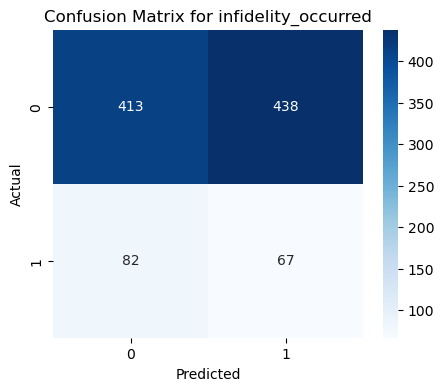


Target: domestic_violence_history — Accuracy: 0.5120


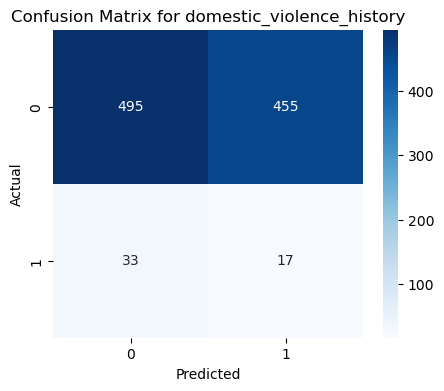


Target: mental_health_issues — Accuracy: 0.5140


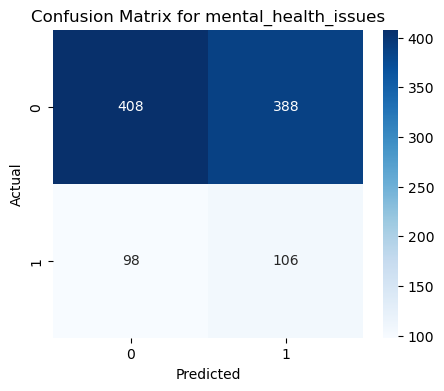

In [103]:
for target in target_cols:
    cm = confusion_matrix(Y_test[target], y_pred_df[target])
    acc = accuracy_score(Y_test[target], y_pred_df[target])
    
    print(f"\nTarget: {target} — Accuracy: {acc:.4f}")
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix for {target}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()